In [3]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

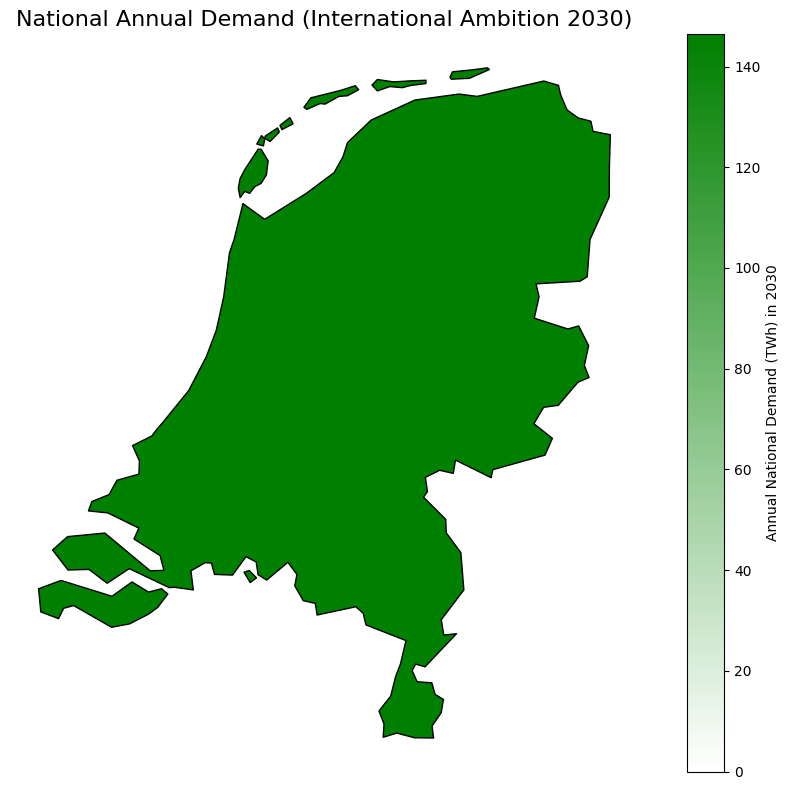

In [36]:
boundaries_country_file = "ip2024_ia_2030/boundaries_NUTS0_filtered_NL.geojson"
hourly_demand_file = "ip2024_ia_2030/ip2024_international_ambition.csv"

# Read the GeoJSON file for the Netherlands boundary
boundaries_country = gpd.read_file(boundaries_country_file)

# Read the hourly national demand data
hourly_demand = pd.read_csv(hourly_demand_file, parse_dates=["time"])

# calculate annual demand for the entire country
hourly_demand["year"] = hourly_demand["time"].dt.year
annual_demand = hourly_demand.groupby("year")["NL"].sum()  # Total GWh per year
annual_demand_twh = annual_demand / 1000.0  # Convert GWh to TWh

year_to_plot = 2030
demand_value_twh = annual_demand_twh.loc[year_to_plot]

# Add the national demand as a column to the GeoDataFrame
boundaries_country["annual_demand"] = demand_value_twh

# plot the map
greens = LinearSegmentedColormap.from_list("greens", ["white", "green"])

fig, ax = plt.subplots(1, 1, figsize=(10, 8))
boundaries_country.plot(
    column="annual_demand",
    cmap=greens,
    legend=True,
    legend_kwds={
        "label": f"Annual national demand (TWh) in {year_to_plot}",
        "orientation": "vertical",
    },
    vmin=0,  # Start color scale at 0
    vmax=demand_value_twh,
    ax=ax,
    edgecolor="black",
)

ax.set_title("National annual demand (International Ambition 2030)", fontsize=16)
ax.axis("off")

plt.tight_layout()
plt.savefig("national_annual_demand_map.pdf", dpi=300, bbox_inches="tight")
plt.show()

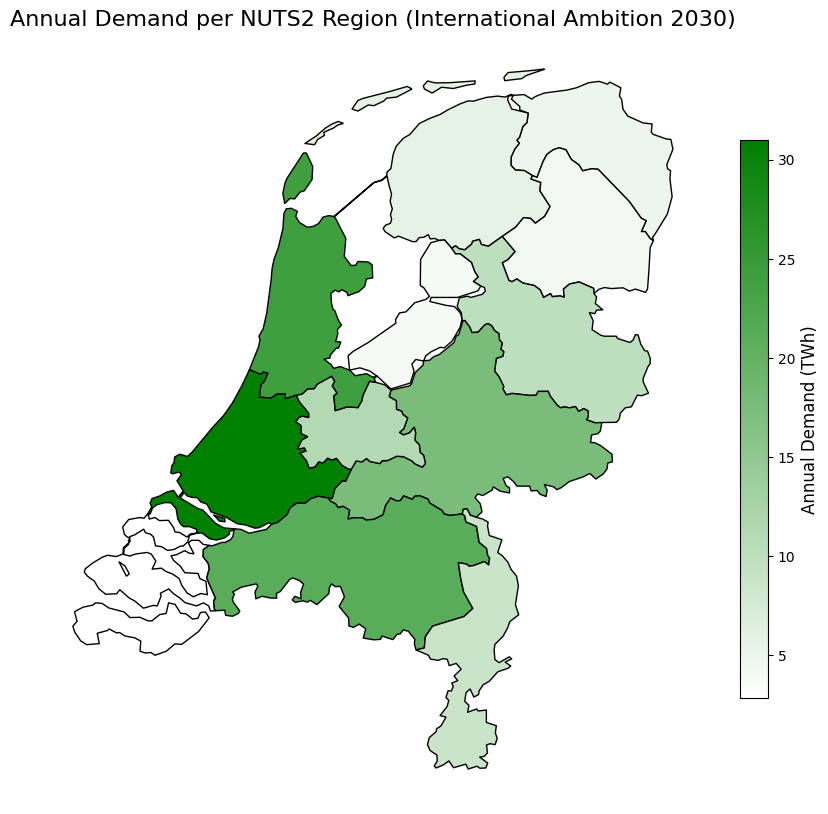

In [8]:
#This notebook is used to plot the distribution of the electricity demand in each of the 2030 scenarios (IA, ND, KA)

# File paths
boundaries_country_file = "ip2024_ia_2030/boundaries_NUTS0_filtered_NL.geojson"
boundaries_NUTS2_file = "ip2024_ia_2030/NUTS_RG_20M_2024_3035_modified.geojson"
aggregated_demand_file = "ip2024_ia_2030/aggregated_demand_NUTS2_ia_2030_final.csv"
boundaries_country = gpd.read_file(boundaries_country_file)
boundaries_NUTS2 = gpd.read_file(boundaries_NUTS2_file)
demand_data = pd.read_csv(aggregated_demand_file, parse_dates=["time"])

# Aggregate demand annually per NUTS2 region
demand_data["year"] = demand_data["time"].dt.year
annual_demand = demand_data.groupby("year").sum(numeric_only=True)  # Summing all regions for the year

# Match demand data with NUTS2 boundaries
boundaries_NUTS2["NUTS_ID"] = boundaries_NUTS2["NUTS_ID"].astype(str)
annual_demand_total = demand_data.drop(columns=["time", "year"]).sum().reset_index()
annual_demand_total.columns = ["NUTS_ID", "annual_demand"]

# Convert demand from GWh to TWh
annual_demand_total["annual_demand"] = annual_demand_total["annual_demand"] / 1000.0  # Convert GWh to TWh

# Merge demand with NUTS2 boundaries
nuts2_with_demand = boundaries_NUTS2.merge(annual_demand_total, on="NUTS_ID", how="left")

greens = LinearSegmentedColormap.from_list("greens", ["white", "green"])

# Plot
fig, ax = plt.subplots(1, 1, figsize=(12, 10))
cbar = plt.cm.ScalarMappable(cmap=greens, norm=plt.Normalize(vmin=nuts2_with_demand["annual_demand"].min(), 
                                                              vmax=nuts2_with_demand["annual_demand"].max()))
nuts2_with_demand.plot(
    column="annual_demand",
    cmap=greens,
    legend=False,
    ax=ax,
    edgecolor="black",
)

# Title and colorbar
ax.set_title("Annual demand per NUTS2 region (International Ambition 2030)", fontsize=16)
ax.axis("off")

# Color scale
cbar = fig.colorbar(cbar, ax=ax, orientation="vertical", fraction=0.03, pad=0.04)
cbar.set_label("Annual demand (TWh)", fontsize=12)

# Show and save
plt.savefig("annual_demand_NUTS2_ia.pdf", dpi=300, bbox_inches="tight")
plt.show()


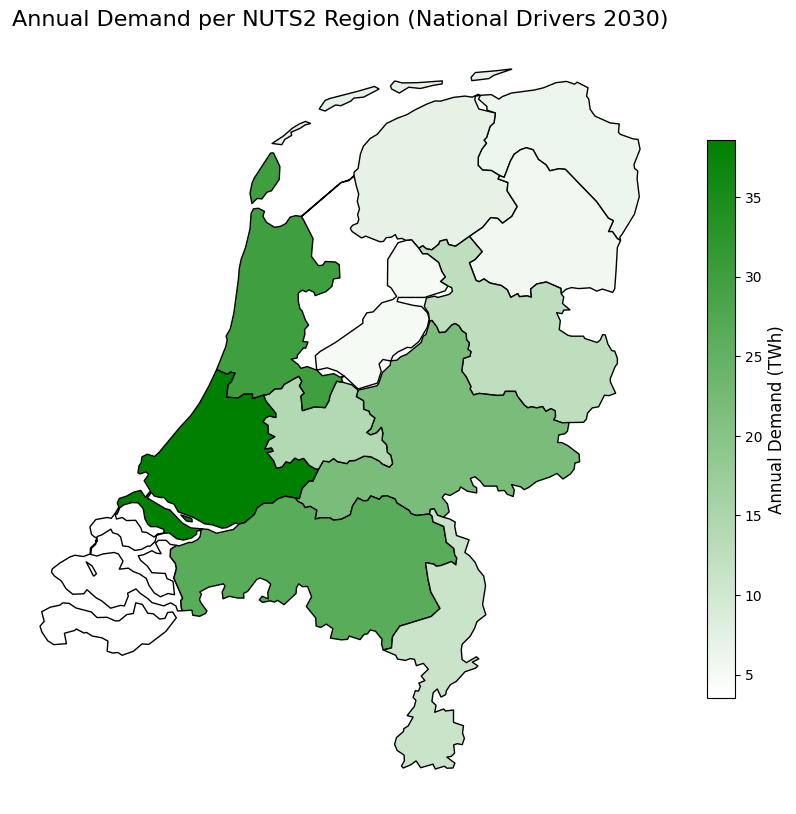

In [4]:
#This notebook is used to plot the distribution of the electricity demand in each of the 2030 scenarios (IA, ND, KA)

# File paths
boundaries_country_file = "ip2024_nd_2030/boundaries_NUTS0_filtered_NL.geojson"
boundaries_NUTS2_file = "ip2024_nd_2030/NUTS_RG_20M_2024_3035_modified.geojson"
aggregated_demand_file = "ip2024_nd_2030/aggregated_demand_NUTS2_nd_2030.csv"
boundaries_country = gpd.read_file(boundaries_country_file)
boundaries_NUTS2 = gpd.read_file(boundaries_NUTS2_file)
demand_data = pd.read_csv(aggregated_demand_file, parse_dates=["time"])

# Aggregate demand annually per NUTS2 region
demand_data["year"] = demand_data["time"].dt.year
annual_demand = demand_data.groupby("year").sum(numeric_only=True)  # Summing all regions for the year

# Match demand data with NUTS2 boundaries
boundaries_NUTS2["NUTS_ID"] = boundaries_NUTS2["NUTS_ID"].astype(str)
annual_demand_total = demand_data.drop(columns=["time", "year"]).sum().reset_index()
annual_demand_total.columns = ["NUTS_ID", "annual_demand"]

# Convert demand from GWh to TWh
annual_demand_total["annual_demand"] = annual_demand_total["annual_demand"] / 1000.0  # Convert GWh to TWh

# Merge demand with NUTS2 boundaries
nuts2_with_demand = boundaries_NUTS2.merge(annual_demand_total, on="NUTS_ID", how="left")

# Define custom greens colormap
greens = LinearSegmentedColormap.from_list("greens", ["white", "green"])

# Plot
fig, ax = plt.subplots(1, 1, figsize=(12, 10))
cbar = plt.cm.ScalarMappable(cmap=greens, norm=plt.Normalize(vmin=nuts2_with_demand["annual_demand"].min(), 
                                                              vmax=nuts2_with_demand["annual_demand"].max()))
nuts2_with_demand.plot(
    column="annual_demand",
    cmap=greens,
    legend=False,
    ax=ax,
    edgecolor="black",
)

# Title and colorbar
ax.set_title("Annual Demand per NUTS2 Region (National Drivers 2030)", fontsize=16)
ax.axis("off")

# Color scale
cbar = fig.colorbar(cbar, ax=ax, orientation="vertical", fraction=0.03, pad=0.04)
cbar.set_label("Annual Demand (TWh)", fontsize=12)

# Show and save
plt.savefig("annual_demand_NUTS2_nd.pdf", dpi=300, bbox_inches="tight")
plt.show()


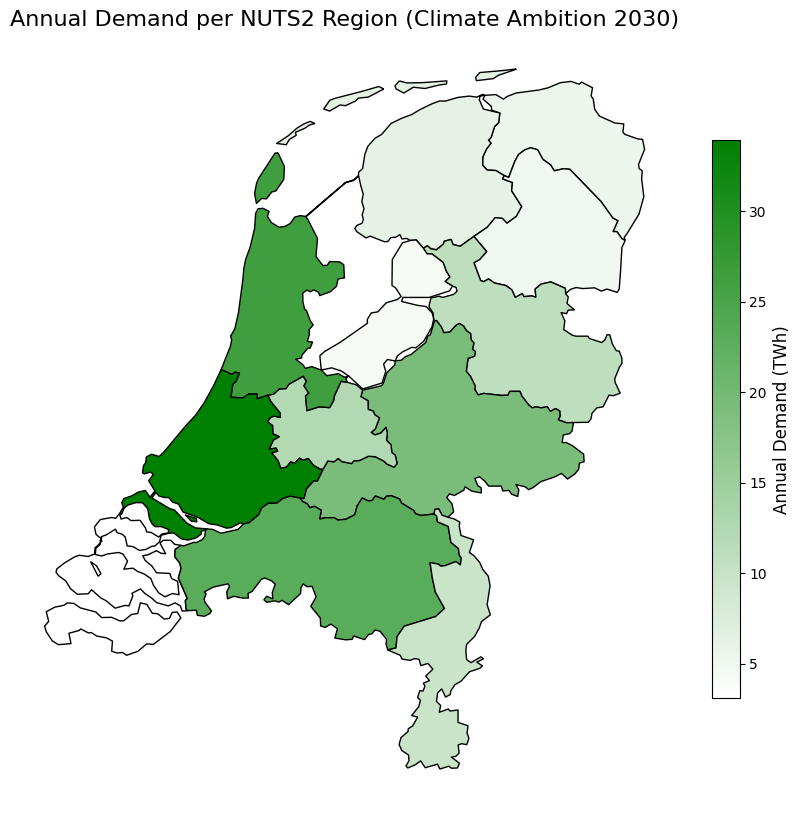

In [9]:
#This notebook is used to plot the distribution of the electricity demand in each of the 2030 scenarios (IA, ND, KA)

# File paths
boundaries_country_file = "ip2024_ka_2030/boundaries_NUTS0_filtered_NL.geojson"
boundaries_NUTS2_file = "ip2024_ka_2030/NUTS_RG_20M_2024_3035_modified.geojson"
aggregated_demand_file = "ip2024_ka_2030/aggregated_demand_NUTS2_ka_2030.csv"
boundaries_country = gpd.read_file(boundaries_country_file)
boundaries_NUTS2 = gpd.read_file(boundaries_NUTS2_file)
demand_data = pd.read_csv(aggregated_demand_file, parse_dates=["time"])

# Aggregate demand annually per NUTS2 region
demand_data["year"] = demand_data["time"].dt.year
annual_demand = demand_data.groupby("year").sum(numeric_only=True)  # Summing all regions for the year

# Match demand data with NUTS2 boundaries
boundaries_NUTS2["NUTS_ID"] = boundaries_NUTS2["NUTS_ID"].astype(str)
annual_demand_total = demand_data.drop(columns=["time", "year"]).sum().reset_index()
annual_demand_total.columns = ["NUTS_ID", "annual_demand"]

# Convert demand from GWh to TWh
annual_demand_total["annual_demand"] = annual_demand_total["annual_demand"] / 1000.0  # Convert GWh to TWh

# Merge demand with NUTS2 boundaries
nuts2_with_demand = boundaries_NUTS2.merge(annual_demand_total, on="NUTS_ID", how="left")

# Define custom greens colormap
greens = LinearSegmentedColormap.from_list("greens", ["white", "green"])

# Plot
fig, ax = plt.subplots(1, 1, figsize=(12, 10))
cbar = plt.cm.ScalarMappable(cmap=greens, norm=plt.Normalize(vmin=nuts2_with_demand["annual_demand"].min(), 
                                                              vmax=nuts2_with_demand["annual_demand"].max()))
nuts2_with_demand.plot(
    column="annual_demand",
    cmap=greens,
    legend=False,
    ax=ax,
    edgecolor="black",
)

# Title and colorbar
ax.set_title("Annual demand per NUTS2 region (Climate Ambition 2030)", fontsize=16)
ax.axis("off")

# Color scale
cbar = fig.colorbar(cbar, ax=ax, orientation="vertical", fraction=0.03, pad=0.04)
cbar.set_label("Annual demand (TWh)", fontsize=12)

# Show and save
plt.savefig("annual_demand_NUTS2_ka.pdf", dpi=300, bbox_inches="tight")
plt.show()


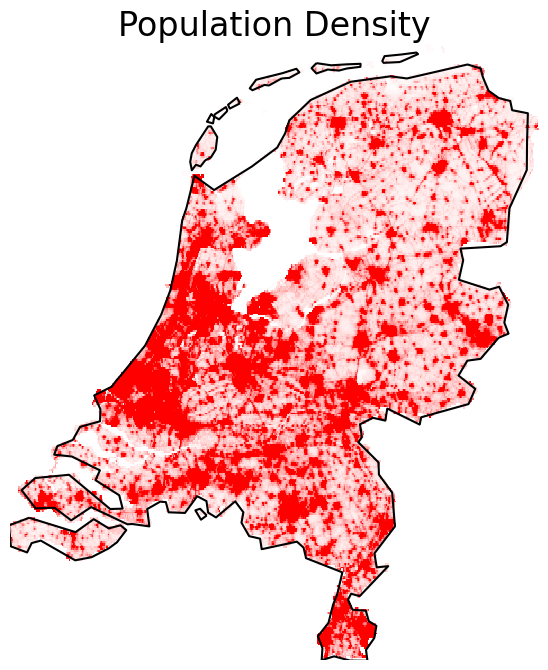

In [45]:
# File paths
population_file = "ip2024_ka_2030/nld_pd_2020_1km.tif"
boundaries_country_file = "ip2024_ia_2030/boundaries_NUTS0_filtered_NL.geojson"

# Read the population raster and boundaries
population = rxr.open_rasterio(population_file, masked=True)
boundaries_country = gpd.read_file(boundaries_country_file)

# Extract the first band (assume single-band raster for population data)
if population.rio.count != 1:
    population = population.isel(band=0)

# Step 1: Plot the population raster
fig, ax = plt.subplots(1, 1, figsize=(12, 8))

reds = LinearSegmentedColormap.from_list("reds", ["white", "red"])
population.rio.reproject("EPSG:4236").plot(
    ax=ax,
    cmap=reds,
    vmin=0,  # Ensure the color scale starts at 0
    vmax=500,
    add_colorbar=False  # Skip the color bar
)
boundaries_country.geometry.boundary.plot(ax=ax, color="black")

# Title and axis settings
ax.set_title("Population density", fontsize=24, loc="center")
ax.set_axis_off()

# Save and display the plot
plt.savefig("population_density_map_no_colorbar.pdf", dpi=300, bbox_inches="tight")
plt.show()

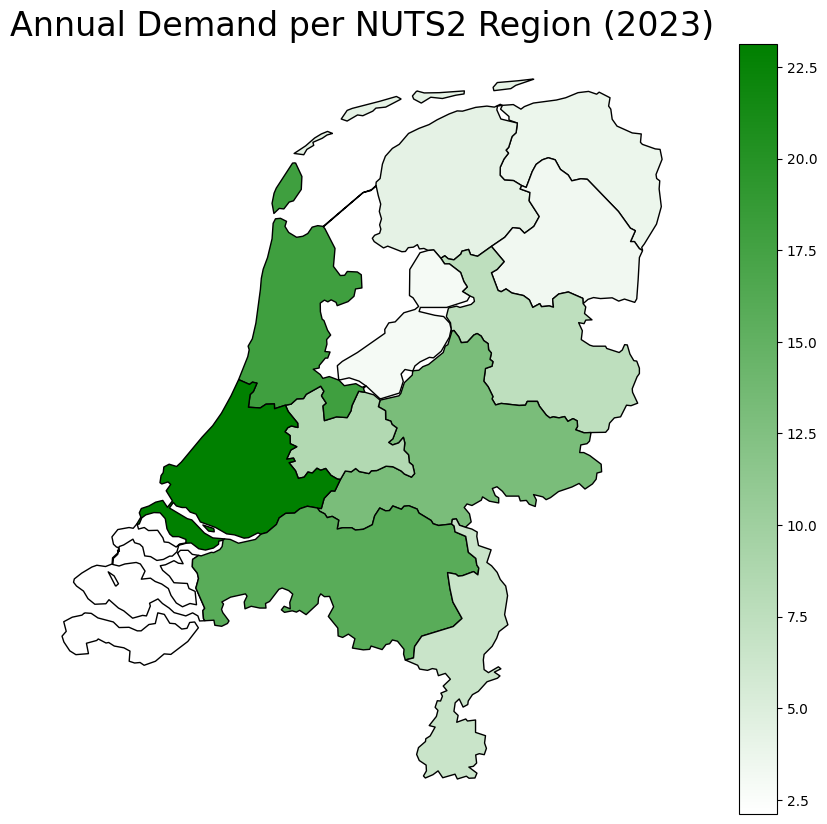

In [47]:
# File paths
boundaries_country_file = "historic_2023/boundaries_NUTS0_filtered_NL.geojson"
boundaries_NUTS2_file = "historic_2023/NUTS_RG_20M_2024_3035_modified.geojson"
aggregated_demand_file = "historic_2023/aggregated_demand_time_first.csv"

# Read the GeoJSON and demand data
boundaries_country = gpd.read_file(boundaries_country_file)
boundaries_NUTS2 = gpd.read_file(boundaries_NUTS2_file)
demand_data = pd.read_csv(aggregated_demand_file, parse_dates=["time"])

# Aggregate demand annually per NUTS2 region
demand_data["year"] = demand_data["time"].dt.year
annual_demand = demand_data.groupby("year").sum(numeric_only=True)  # Summing all regions for the year

# Match demand data with NUTS2 boundaries
boundaries_NUTS2["NUTS_ID"] = boundaries_NUTS2["NUTS_ID"].astype(str)
annual_demand_total = demand_data.drop(columns=["time", "year"]).sum().reset_index()
annual_demand_total.columns = ["NUTS_ID", "annual_demand"]

# Make all demand values positive
annual_demand_total["annual_demand"] = annual_demand_total["annual_demand"].abs()

# Convert demand from GWh to TWh
annual_demand_total["annual_demand"] = annual_demand_total["annual_demand"] / 1000.0  # Convert GWh to TWh

# Merge demand data with NUTS2 boundaries
nuts2_with_demand = boundaries_NUTS2.merge(annual_demand_total, on="NUTS_ID", how="left")

#Define a custom greens colormap
greens = LinearSegmentedColormap.from_list("greens", ["white", "green"])

# Plot the data
fig, ax = plt.subplots(1, 1, figsize=(12, 10))
cbar = plt.cm.ScalarMappable(
    cmap=greens, norm=plt.Normalize(vmin=nuts2_with_demand["annual_demand"].min(), 
                                    vmax=nuts2_with_demand["annual_demand"].max())
)
nuts2_with_demand.plot(
    column="annual_demand",
    cmap=greens,
    legend=True,
    ax=ax,
    edgecolor="black",
)

# Add title and colorbar
ax.set_title("Annual Demand per NUTS2 Region (2023)", fontsize=24,loc="center")
ax.axis("off")

# Save and display the plot
plt.savefig("annual_demand_NUTS2_2023.pdf", dpi=300, bbox_inches="tight")
plt.show()

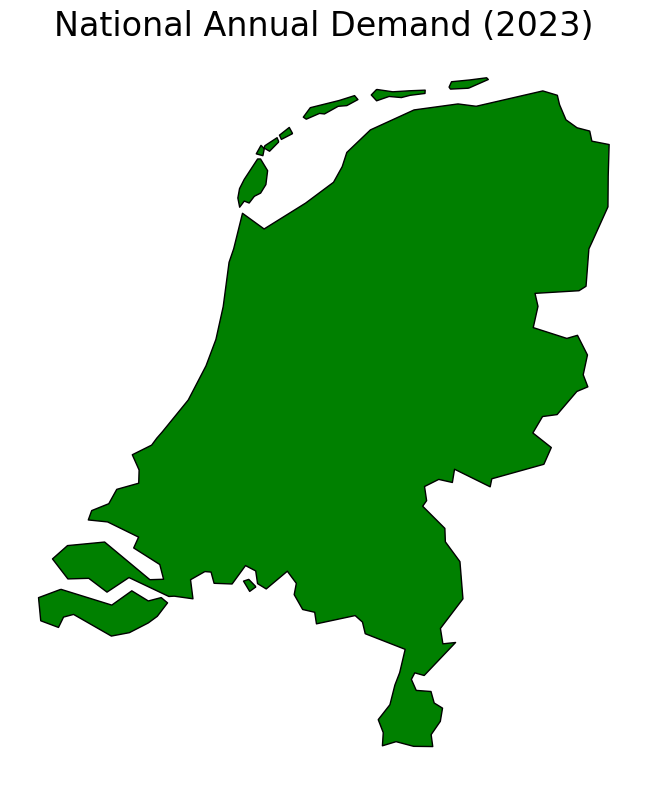

In [42]:
# File paths
boundaries_country_file = "historic_2023/boundaries_NUTS0_filtered_NL.geojson"
hourly_demand_file = "historic_2023/demand_elc.csv"

# Read the GeoJSON file for the Netherlands boundary
boundaries_country = gpd.read_file(boundaries_country_file)

# Read the hourly national demand data
hourly_demand = pd.read_csv(hourly_demand_file, parse_dates=["time"])

# Calculate annual demand for the entire country
hourly_demand["year"] = hourly_demand["time"].dt.year
hourly_demand["NL"] = hourly_demand["NL"].abs()  # Ensure all demand values are positive
annual_demand = hourly_demand.groupby("year")["NL"].sum()  # Total GWh per year
annual_demand_twh = annual_demand / 1000.0  # Convert GWh to TWh

# Select the specific year to plot (e.g., 2023)
year_to_plot = 2050
demand_value_twh = annual_demand_twh.loc[year_to_plot]

# Add the national demand as a column to the GeoDataFrame
boundaries_country["annual_demand"] = demand_value_twh

# Define a green colormap
greens = LinearSegmentedColormap.from_list("greens", ["white", "green"])

# Plot the map
fig, ax = plt.subplots(1, 1, figsize=(12, 8))
boundaries_country.plot(
    column="annual_demand",
    cmap=greens,
    legend=False,
    legend_kwds={
        "label": f"Annual National Demand (TWh) in {year_to_plot}",
        "orientation": "vertical",
    },
    vmin=0,  # Start color scale at 0
    vmax=demand_value_twh,
    ax=ax,
    edgecolor="black",
)

# Add title
ax.set_title("National annual demand (2023)", fontsize=24, loc="center")
ax.axis("off")

# Save and show the plot
plt.tight_layout()
plt.savefig("national_annual_demand_map_2023.pdf", dpi=300, bbox_inches="tight")
plt.show()